# Zomato Data Analysis Project

# Step 1: Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Create the data frame

In [2]:
dataframe = pd.read_csv("Zomato data .csv")

In [3]:
print(dataframe)

                      name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2                            8

# Convert the data type of column- rate

In [4]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# What type of resturant do the majority of customers order from?

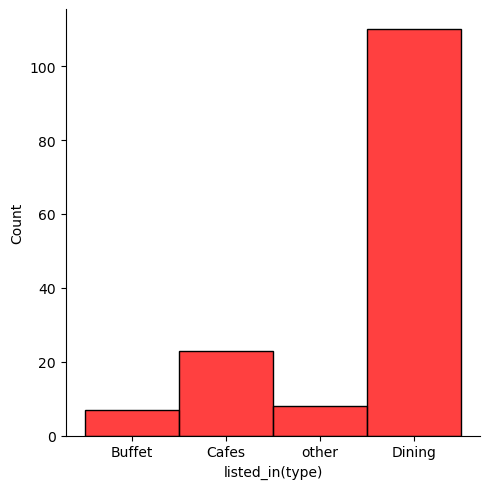

In [6]:
sns.displot(data = dataframe, x = "listed_in(type)",color = "Red")
plt.show()

# How many votes has each type of resturant received from customers?

Text(0, 0.5, 'votes')

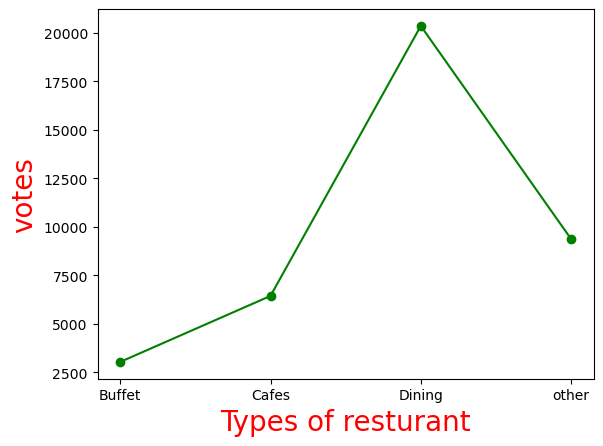

In [7]:
grouped_data = dataframe.groupby('listed_in(type)')["votes"].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c = "green", marker = "o")
plt.xlabel("Types of resturant", c = "red", size = 20)
plt.ylabel("votes", c = "red", size = 20)

# What are the ratings that the majority of resturants have recieved ?

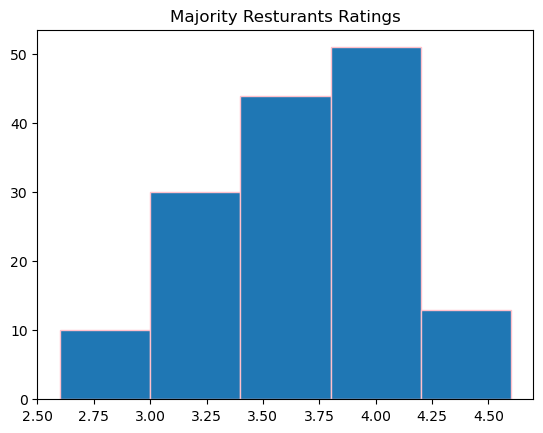

In [8]:
plt.hist(dataframe['rate'], bins = 5, edgecolor = "pink")
plt.title("Majority Resturants Ratings")
plt.show()

# Zomato has observed that most coples order most of their food online. What is thier average spending on each order?

In [9]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [18]:
online = dataframe[dataframe["online_order"] == "Yes"]

# Mathematical Calculation

In [19]:
average = online["approx_cost(for two people)"].mean()
print(average)

510.3448275862069


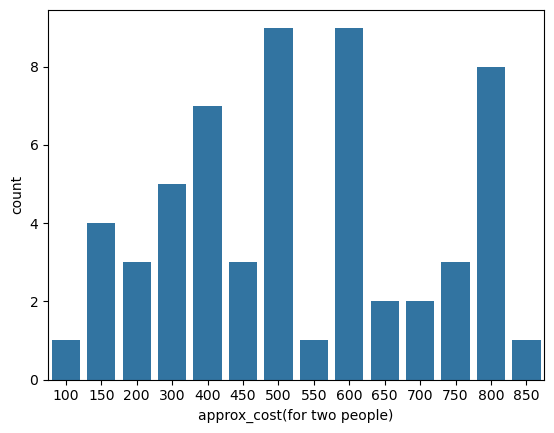

In [21]:
sns.countplot(x = "approx_cost(for two people)", data = online)
plt.show()

# Which mode(online or offline) have recieved the maximum ratings? 

In [24]:
offline = dataframe[dataframe["online_order"] == "No"]

# Mathematical calculation for maximum ratings.

In [31]:
online_rating = online["rate"].mean()
print(online_rating)

3.8586206896551727


In [28]:
offline_rating = offline["rate"].mean()
print(offline_rating)

3.4877777777777768


# Through Visulaziation

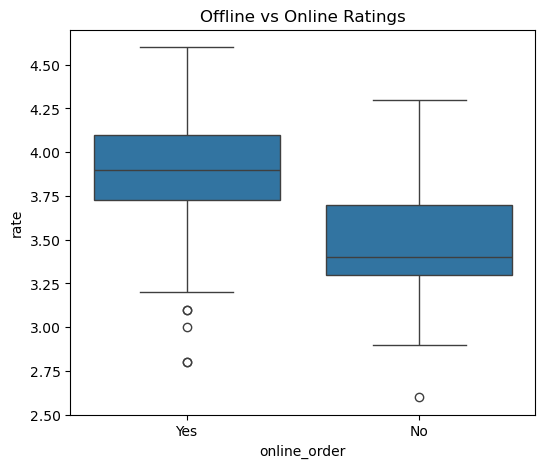

In [35]:
plt.figure(figsize = (6,5))
sns.boxplot(x = "online_order", y = "rate", data = dataframe)
plt.title("Offline vs Online Ratings")
plt.show()

# Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

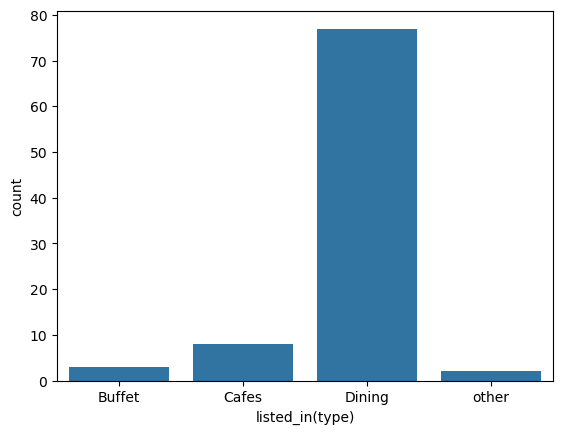

In [38]:
sns.countplot(x = "listed_in(type)", data = offline)
plt.show()